# Clustering decisions: embedded text, embedding model and cluster settings

This notebook records **why** the clustering step of the v2 pipeline is set up the way it is.
Each decision is made from evidence computed below, in this order:

1. **What text to embed** for each posting
2. **Which embedding model** turns that text into vectors
3. **How much text the model reads at once** (chunking)
4. **UMAP and HDBSCAN settings**, tuned separately for the AV-relevant and the other group

**Constraints**
- **No LLM calls.** Every posting's record is read from the pipeline's database,
  `output_full/av_job_profiles.sqlite`. Analysis run 1 is the full run (`openai/gpt-6-luna`, prompt
  `p5`), and its stored clusters are the original clustering this notebook re-examines. Later runs
  reuse the same records.
- Everything runs on this machine. Embedding models are downloaded once from Hugging Face.
- Embeddings and grid results are cached in `.cache/notebook_emb/`, so re-running is fast.

In [1]:
import sqlite3
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import cluster_eval as ce

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 90)

df = ce.load_postings(run_id=1)
groups = {"AV-relevant": df.av_relevant.to_numpy(), "not AV-relevant": ~df.av_relevant.to_numpy()}
print(f"{len(df):,} postings from analysis run {df.attrs['analysis_run_id']}")
print({g: int(m.sum()) for g, m in groups.items()})

4,518 postings from analysis run 1
{'AV-relevant': 2902, 'not AV-relevant': 1616}


## 1. How the options are judged without labelled data

There is no hand-labelled "true" grouping of these 4,518 postings, so each option is judged against
**information the embedding never sees**:

| Metric | What it measures | Better |
|---|---|---|
| `title_lift` | Title-word overlap between a posting and its 10 nearest neighbours **from other companies**, divided by the overlap of random other-company pairs. Titles are not part of the embedded text, so this is an independent check that neighbours do the same kind of job. | higher |
| `employer_ratio` | Share of a posting's 10 nearest neighbours from its **own** company, divided by the share expected by chance. 1.0 means the employer doesn't matter. | closer to 1 |
| `av_agreement` | Share of neighbours in the same AV / non-AV group. A sanity check only. | higher |

These metrics compare **rankings of neighbours**, not raw similarity values, so models whose
similarity scores sit on different scales can be compared fairly.

**Choices made in the metrics**
- **Level words are removed from titles** (senior, staff, lead, intern, …), and so are brackets, gender
  tags and filler. The check then rewards neighbours doing the same **role**, whatever their level.
- **Only other-company neighbours count** for `title_lift`, so reposts of one ad cannot inflate it.

**Caveats**
- Titles are marketing text: the same job can be titled differently.
- Some employer effect is genuine. For example, Bosch's heating-sales roles only exist at Bosch.

The metrics are therefore used to **compare options**, not as absolute scores.

**When is a difference real?** Two options are always scored on the **same postings**, so the fair
test is paired: take each posting's score under option A minus under option B, resample postings
1,000 times (bootstrap), and read the 95% interval of the mean difference. If that interval contains
0, the options can't be told apart on this data.

In [2]:
examples = ["Senior Machine Learning Engineer - Perception", "[D-Robotics] PCB Engineer",
            "Mandatory internship in production planning (f/m/div.)",
            "Autonomous Vehicle Operator, Houston (AM Shift, 12-Month Contract)"]
for t in examples:
    print(f"{t!r:75} -> {sorted(ce.title_tokens(t))}")
print(f"\nrandom other-company title overlap (Jaccard): {ce.random_title_baseline(df):.3f}")

'Senior Machine Learning Engineer - Perception'                             -> ['engineer', 'learning', 'machine', 'perception']
'[D-Robotics] PCB Engineer'                                                 -> ['engineer', 'pcb']
'Mandatory internship in production planning (f/m/div.)'                    -> ['planning', 'production']
'Autonomous Vehicle Operator, Houston (AM Shift, 12-Month Contract)'        -> ['autonomous', 'houston', 'operator', 'vehicle']

random other-company title overlap (Jaccard): 0.048


## 2. Decision 1: what text to embed

The pipeline currently embeds the model's **role summary + responsibilities + every skill name**
(`A_all_skills`). The hypothesis is that generic skills make unrelated postings look alike:
qualifications such as "Bachelor's degree", and tools that appear everywhere.

Four variants are compared:

| Variant | Text |
|---|---|
| `A_all_skills` | summary + responsibilities + tools, domain and qualification names (current) |
| `B_no_qualifications` | summary + responsibilities + tools and domain names |
| `C_work_only` | summary + responsibilities |
| `D_summary_only` | the 2–3 sentence summary |

First, how common the most frequent skills are, read from the database's `job_skills` table:

In [3]:
con = sqlite3.connect(ce.DB_PATH)
top = pd.read_sql('''
    SELECT s.canonical_name AS skill, s.skill_type AS type,
           COUNT(DISTINCT js.job_analysis_id) AS postings
    FROM job_skills js JOIN skills s USING (skill_id)
    JOIN job_analyses a USING (job_analysis_id)
    WHERE a.analysis_run_id = (SELECT MAX(analysis_run_id) FROM analysis_runs)
    GROUP BY s.skill_id ORDER BY postings DESC LIMIT 12''', con)
top["share_of_postings"] = (top.postings / len(df)).round(2)
top

,skill,type,postings,share_of_postings
0,Bachelor's degree,qualification,2341,0.52
1,Python,tool,1531,0.34
2,C++,tool,972,0.22
3,Master's degree,qualification,825,0.18
4,Autonomous driving,domain,659,0.15
5,Linux,tool,566,0.13
6,PyTorch,tool,360,0.08
7,Machine learning,domain,348,0.08
8,MS Office,tool,343,0.08
9,Robotics,domain,342,0.08


Each variant is embedded with each of the six candidate models (next section) and scored with the
metrics above. A variant is only worth choosing if it wins **across models**, not just with one.

**Rule:** choose the variant with the best average rank across the six models, and check with paired
intervals whether its lead over each alternative is real.

In [4]:
BASE = ce.random_title_baseline(df)
rows, per_posting = [], {}
for model in ce.MODELS:
    for variant in ce.TEXT_VARIANTS:
        vecs, _ = ce.embed(ce.texts(df, variant), model)
        per_posting[(model, variant)] = ce.title_agreement(vecs, df)
        rows.append({"model": model, "variant": variant, **ce.neighbour_metrics(vecs, df)})
grid = pd.DataFrame(rows).round(3)
print("title_lift (higher is better)")
grid.pivot(index="variant", columns="model", values="title_lift")

title_lift (higher is better)


model,all-MiniLM-L6-v2,all-mpnet-base-v2,bge-base-en-v1.5,bge-large-en-v1.5,e5-base-v2,gte-base
variant,,,,,,
A_all_skills,3.807,3.740,3.971,4.049,3.850,3.970
B_no_qualifications,3.791,3.726,3.940,4.016,3.820,3.939
C_work_only,3.650,3.569,3.746,3.859,3.603,3.754
D_summary_only,3.613,3.609,3.912,3.937,3.848,3.967


In [5]:
print("employer_ratio (closer to 1 is better)")
grid.pivot(index="variant", columns="model", values="employer_ratio")

employer_ratio (closer to 1 is better)


model,all-MiniLM-L6-v2,all-mpnet-base-v2,bge-base-en-v1.5,bge-large-en-v1.5,e5-base-v2,gte-base
variant,,,,,,
A_all_skills,3.133,3.196,3.203,3.262,3.181,3.177
B_no_qualifications,3.110,3.182,3.193,3.238,3.130,3.173
C_work_only,3.088,3.165,3.184,3.238,3.094,3.159
D_summary_only,3.012,2.987,3.085,3.104,3.072,3.145


In [6]:
# Rank each variant within each model (1 = best title_lift), then average across models.
grid["rank_in_model"] = grid.groupby("model").title_lift.rank(ascending=False)
summary = grid.groupby("variant").agg(mean_rank=("rank_in_model", "mean"),
                                      mean_title_lift=("title_lift", "mean"),
                                      mean_employer_ratio=("employer_ratio", "mean")).round(3)
summary.sort_values("mean_rank")

,mean_rank,mean_title_lift,mean_employer_ratio
variant,,,
A_all_skills,1.000,3.898,3.192
B_no_qualifications,2.333,3.872,3.171
D_summary_only,2.833,3.814,3.068
C_work_only,3.833,3.697,3.155


In [7]:
# Rule: the variant with the best average rank across the six models.
CHOSEN_TEXT = summary.sort_values("mean_rank").index[0]
print("chosen text variant:", CHOSEN_TEXT)

# Is its lead real? Paired difference (chosen minus alternative), per model, 95% interval.
rows = []
for model in ce.MODELS:
    for variant in ce.TEXT_VARIANTS:
        if variant == CHOSEN_TEXT:
            continue
        d, lo, hi = ce.paired_difference(per_posting[(model, CHOSEN_TEXT)], per_posting[(model, variant)], BASE)
        rows.append({"model": model, "vs": variant, "difference": f"{d:+.3f} [{lo:+.3f}, {hi:+.3f}]",
                     "real": "yes" if lo > 0 else ("worse" if hi < 0 else "tie")})
pd.DataFrame(rows).pivot(index="model", columns="vs", values="difference")

chosen text variant: A_all_skills


vs,B_no_qualifications,C_work_only,D_summary_only
model,,,
all-MiniLM-L6-v2,"+0.000 [-0.022, +0.022]","+0.128 [+0.092, +0.170]","+0.161 [+0.107, +0.215]"
all-mpnet-base-v2,"+0.008 [-0.011, +0.030]","+0.156 [+0.119, +0.192]","+0.104 [+0.055, +0.157]"
bge-base-en-v1.5,"+0.023 [+0.003, +0.044]","+0.163 [+0.125, +0.202]","+0.057 [+0.008, +0.104]"
bge-large-en-v1.5,"+0.020 [-0.002, +0.041]","+0.152 [+0.107, +0.195]","+0.068 [+0.009, +0.118]"
e5-base-v2,"+0.013 [-0.014, +0.038]","+0.153 [+0.114, +0.193]","-0.029 [-0.078, +0.022]"
gte-base,"+0.021 [+0.003, +0.039]","+0.151 [+0.114, +0.190]","+0.026 [-0.025, +0.075]"


**Finding (decision 1): keep the current text, `A_all_skills`.**

- **It ranks first with all six models.**
- **Dropping every skill (C) is clearly worse with every model:** −0.13 to −0.16, with intervals far from 0. The skill names carry real information about the work.
- **Dropping only the qualifications (B) makes no meaningful difference:** within noise for three models, and slightly worse (about −0.02) for the other three.

The starting hypothesis, that generic qualifications such as "Bachelor's degree" blur the picture, is **not supported**. Qualifications are only about 7% of skill mentions, and they appear in postings of every kind, so they shift all vectors alike instead of pulling unrelated postings together.

**The summary alone (D)** is competitive with some models but is never the best.

## 3. Decision 2: which embedding model

Six local models are compared on the chosen text. `all-MiniLM-L6-v2` is the current one: small, fast,
and it reads at most 256 word-pieces. The others are larger general-purpose embedding models. They
are all free to run locally, and they rank well on public clustering benchmarks.

| Model | Size | Reads up to |
|---|---|---|
| all-MiniLM-L6-v2 | 22M parameters, 384 dims | 256 tokens |
| all-mpnet-base-v2 | 110M, 768 dims | 384 tokens |
| bge-base-en-v1.5 | 110M, 768 dims | 512 tokens |
| e5-base-v2 | 110M, 768 dims (texts prefixed with `query: `, as its authors specify for clustering) | 512 tokens |
| gte-base | 110M, 768 dims | 512 tokens |
| bge-large-en-v1.5 | 335M, 1024 dims | 512 tokens |

In [8]:
t = ce.texts(df, CHOSEN_TEXT)
rows = []
for model in ce.MODELS:
    vecs, _ = ce.embed(t, model)
    rows.append({"model": model, "dims": vecs.shape[1], **ce.neighbour_metrics(vecs, df)})
models = pd.DataFrame(rows).round(3).sort_values("title_lift", ascending=False)
models

,model,dims,title_lift,employer_ratio,av_agreement
5,bge-large-en-v1.5,1024,4.049,3.262,0.862
2,bge-base-en-v1.5,768,3.971,3.203,0.862
4,gte-base,768,3.970,3.177,0.860
3,e5-base-v2,768,3.850,3.181,0.855
0,all-MiniLM-L6-v2,384,3.807,3.133,0.859
1,all-mpnet-base-v2,768,3.740,3.196,0.868


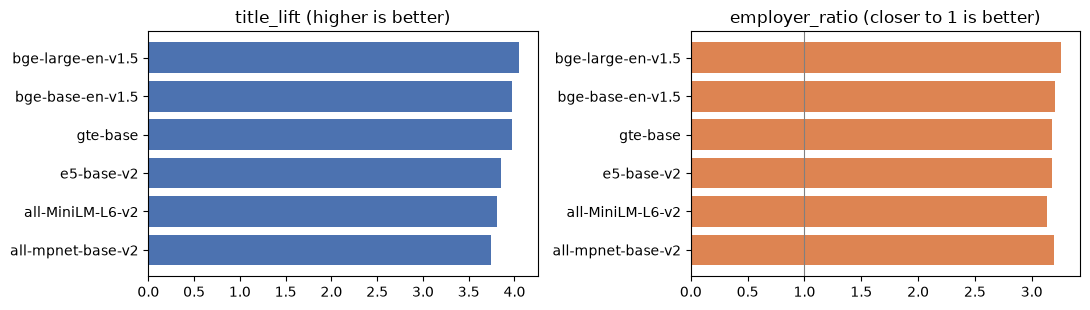

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
m = models.sort_values("title_lift")
ax[0].barh(m.model, m.title_lift, color="#4c72b0"); ax[0].set_title("title_lift (higher is better)")
ax[1].barh(m.model, m.employer_ratio, color="#dd8452"); ax[1].set_title("employer_ratio (closer to 1 is better)")
ax[1].axvline(1, color="grey", lw=0.8)
plt.tight_layout(); plt.show()

In [10]:
# Encoding time on this machine (Apple Silicon GPU), measured without the cache.
import tempfile, pathlib
timing = []
sample = t[:500]
for model in ce.MODELS:
    old = ce.EMB_CACHE
    ce.EMB_CACHE = pathlib.Path(tempfile.mkdtemp())
    _, secs = ce.embed(sample, model)
    ce.EMB_CACHE = old
    timing.append({"model": model, "seconds_per_1000_postings": round(secs * 2, 1)})
timing = pd.DataFrame(timing)
timing

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 37277.88it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 19824.39it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16518.56it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 22112.79it/s]

,model,seconds_per_1000_postings
0,all-MiniLM-L6-v2,2.1
1,all-mpnet-base-v2,13.2
2,bge-base-en-v1.5,10.9
3,e5-base-v2,11.1
4,gte-base,9.2
5,bge-large-en-v1.5,35.4


In [11]:
# Rule: the model with the highest title_lift, unless another model is statistically tied with it
# (paired 95% interval of the difference contains 0); among tied models, prefer the fastest,
# since it keeps the pipeline quick and light for the same quality.
best = models.iloc[0].model
rows = []
for model in models.model:
    d, lo, hi = ce.paired_difference(per_posting[(model, CHOSEN_TEXT)], per_posting[(best, CHOSEN_TEXT)], BASE)
    rows.append({"model": model, "vs_best": f"{d:+.3f} [{lo:+.3f}, {hi:+.3f}]", "tied_with_best": hi >= 0})
paired = pd.DataFrame(rows).merge(timing, on="model").merge(models[["model", "employer_ratio"]], on="model")
tied = paired[paired.tied_with_best]
CHOSEN_MODEL = tied.sort_values("seconds_per_1000_postings").iloc[0].model
print(f"best title_lift: {best}; tied with it: {list(tied.model)}")
print("chosen model:", CHOSEN_MODEL)
paired

best title_lift: bge-large-en-v1.5; tied with it: ['bge-large-en-v1.5', 'gte-base']
chosen model: gte-base


,model,vs_best,tied_with_best,seconds_per_1000_postings,employer_ratio
0,bge-large-en-v1.5,"+0.000 [+0.000, +0.000]",True,35.4,3.262
1,bge-base-en-v1.5,"-0.048 [-0.091, -0.003]",False,10.9,3.203
2,gte-base,"-0.029 [-0.074, +0.016]",True,9.2,3.177
3,e5-base-v2,"-0.183 [-0.226, -0.138]",False,11.1,3.181
4,all-MiniLM-L6-v2,"-0.203 [-0.250, -0.154]",False,2.1,3.133
5,all-mpnet-base-v2,"-0.277 [-0.334, -0.227]",False,13.2,3.196


**Finding (decision 2): `gte-base`.**

- **`bge-large-en-v1.5` scores highest**, with a title_lift of about 4.05.
- **`gte-base` is statistically tied with it** (−0.03, interval [−0.07, +0.02]) and encodes about **4× faster** on this Mac. It also groups slightly less by employer (3.18 vs 3.26).
- **Both are clearly better than the current MiniLM**, by about +0.20 for bge-large.
- **`bge-base` is a little behind bge-large, and that gap is real** (−0.05, interval [−0.09, −0.00]).

**Bigger doesn't automatically mean better:**
- `all-mpnet-base-v2`, often recommended as the stronger sentence-transformers model, is **worse** than MiniLM here.
- `e5-base-v2` is **no better** than MiniLM.

That's why every candidate was measured rather than assumed.

## 4. Decision 3: how much text the model reads at once

The pipeline cuts each text into 160-word chunks, embeds each chunk and averages them. That suited
MiniLM, which stops reading after 256 word-pieces. Most texts here are short, with a median of about
140 words for the current variant. But the chosen model can read 512 tokens (about 350 words), so a
longer chunk would let it see nearly every posting in one pass instead of averaging fragments.

In [12]:
lengths = pd.Series([len(x.split()) for x in t])
print(lengths.describe(percentiles=[.5, .9, .99]).round(0).to_string())
rows, per_chunk = [], {}
for words in (160, 350):
    vecs, _ = ce.embed(t, CHOSEN_MODEL, chunk_words=words)
    per_chunk[words] = ce.title_agreement(vecs, df)
    rows.append({"chunk_words": words, "texts_split": int((lengths > words).sum()),
                 **ce.neighbour_metrics(vecs, df)})
chunks = pd.DataFrame(rows).round(3)
d, lo, hi = ce.paired_difference(per_chunk[350], per_chunk[160], BASE)
print(f"350 minus 160 words: {d:+.3f} [{lo:+.3f}, {hi:+.3f}]")
# Rule: read each posting whole (350) unless that is clearly worse (interval entirely below 0).
CHOSEN_CHUNK = 160 if hi < 0 else 350
print("chosen chunk size:", CHOSEN_CHUNK)
chunks

count    4518.0
mean      144.0
std        48.0
min        13.0
50%       139.0
90%       205.0
99%       296.0
max       466.0


350 minus 160 words: +0.148 [+0.111, +0.190]
chosen chunk size: 350


,chunk_words,texts_split,title_lift,employer_ratio,av_agreement
0,160,1417,3.970,3.177,0.860
1,350,14,4.224,3.439,0.872


**Finding (decision 3): read each posting in one pass (350 words).**

- **Far fewer texts are split:** with 160-word chunks, 1,417 postings (31%) were cut and their pieces averaged. With 350 words, only 14 are.
- **Title agreement improves clearly:** +0.15, interval [+0.11, +0.19].
- **The trade-off:** `employer_ratio` rises from 3.18 to 3.44, so neighbours come from the same company somewhat more often. Reading the whole text also picks up each employer's way of describing work.

The gain on the independent title check is the larger and more certain effect, so 350 is kept. The employer effect is tracked in the tuning through `single_company_pct`.

## 5. Decision 4: UMAP and HDBSCAN settings

Clustering runs separately on each group, as in the pipeline: UMAP compresses the vectors, then
HDBSCAN finds dense groups and leaves the rest as noise. Every combination below is tried on each group:

| Setting | Values | Meaning |
|---|---|---|
| UMAP `n_neighbors` | 15, 30, 50 | how much of the surrounding structure UMAP preserves (larger = broader groups) |
| UMAP `n_components` | 5, 10 | dimensions HDBSCAN works in |
| HDBSCAN `min_cluster_size` | 8, 10, 15, 20, 25, 30, 40 | smallest group that counts as a cluster |
| HDBSCAN `min_samples` | 1, 2, 5 | how strict HDBSCAN is about density (higher = more noise) |

**Metrics per setting**, each **averaged over three UMAP runs** (seeds 42, 7 and 123):
- `n_clusters`
- `noise_pct`
- `largest_pct`: the largest cluster as a % of the group
- `title_coherence_lift`: title overlap between other-company pairs **inside** a cluster, relative to random
- `self_contained`: the median share of a cluster's members whose 15 nearest neighbours (in the full
  embedding) are in the same cluster
- `single_company_pct`: the share of clusters that are at least 80% one company
- `seed_agreement`: the adjusted Rand index between the seed-42 clustering and each other seed's,
  over **all** postings, noise included
- `stability`: the same, but only over postings clustered in both runs (shown for reference)

**Selection rule:**
1. **Admissible settings** keep noise at or below 20%, the largest cluster at or below 10% of the
   group, and `seed_agreement` at or above 0.6. The cluster count must also be something a person can
   label: 20–70 for the AV group and 15–45 for the other group.
2. **Among those**, pick the best mean rank across coherence, self-containment and seed agreement (all
   higher is better) and noise (lower is better). No single metric decides on its own.

**How the rule was revised, and why.** The rule was fixed before any results. A first pass then
exposed two weaknesses, and both were corrected before the choice shown here:
- **Single-seed metrics let accidents decide.** The first version read the metrics from one UMAP run
  (seed 42). On two sets of vectors differing only by floating-point noise, that let the winner flip
  between near-tied settings. The metrics are now averaged over the three seeds.
- **The stability check never bit.** The first version filtered and ranked on `stability`, which
  every setting passed (at least 0.72), because it ignores postings flipping in and out of noise.
  That flipping is exactly how the original clustering failed (section 6). The stricter
  `seed_agreement` replaces it, in both the filter and the ranking.

The grid, the thresholds and the other criteria are unchanged. The robustness check at the end of
this section shows what the revised rule picks on both vector sets.

**Vectors:** from here on, the vectors come from **the pipeline's own embedding code**, using the
model and chunk size chosen above. So the clusters below are exactly the ones the pipeline produces.

In [13]:
import sys
sys.path.insert(0, str(ce.ROOT))
from avjobs import config as cfg, embed as pipeline_embed

assert ce.MODELS[CHOSEN_MODEL]["prefix"] == "", "the pipeline's embed code adds no prefix"
cfg.EMBED_MODEL, cfg.CHUNK_WORDS = ce.MODELS[CHOSEN_MODEL]["id"], CHOSEN_CHUNK
VECS = pipeline_embed.embed_postings(t)
GRID = {"n_neighbors": [15, 30, 50], "n_components": [5, 10],
        "min_cluster_size": [8, 10, 15, 20, 25, 30, 40], "min_samples": [1, 2, 5]}
RULES = {"AV-relevant": dict(max_noise=20, max_largest=10, min_agreement=0.6, n_range=(20, 70)),
         "not AV-relevant": dict(max_noise=20, max_largest=10, min_agreement=0.6, n_range=(15, 45))}
results, chosen = {}, {}
for g, mask in groups.items():
    t0 = time.time()
    results[g] = ce.tune_group(VECS[mask], df[mask].reset_index(drop=True), GRID)
    ranked = ce.select(results[g], **RULES[g])
    chosen[g] = ranked.iloc[0]
    print(f"{g}: {len(results[g])} settings, {len(ranked)} admissible ({time.time() - t0:.0f}s)")

  [embed] cache hit -> emb_63ace654029877de.npy
AV-relevant: 126 settings, 6 admissible (0s)
not AV-relevant: 126 settings, 18 admissible (0s)


In [14]:
cols = ["n_neighbors", "n_components", "min_cluster_size", "min_samples", "n_clusters", "noise_pct",
        "largest_pct", "title_coherence_lift", "self_contained", "seed_agreement", "stability",
        "single_company_pct", "mean_rank"]
print("AV-relevant: top 8 admissible settings")
ce.select(results["AV-relevant"], **RULES["AV-relevant"])[cols].head(8)

AV-relevant: top 8 admissible settings


,n_neighbors,n_components,min_cluster_size,min_samples,n_clusters,noise_pct,largest_pct,title_coherence_lift,self_contained,seed_agreement,stability,single_company_pct,mean_rank
36,15,10,30,1,31,17.47,8.57,2.11,0.68,0.68,0.92,1.07,3.25
37,15,10,30,2,31,17.47,8.57,2.11,0.68,0.68,0.92,1.07,3.25
39,15,10,40,1,25,18.90,8.57,2.03,0.70,0.71,0.89,1.27,3.50
40,15,10,40,2,25,18.90,8.57,2.03,0.70,0.71,0.89,1.27,3.50
33,15,10,25,1,35,16.70,8.57,2.11,0.67,0.64,0.89,1.97,3.75
34,15,10,25,2,35,16.70,8.57,2.11,0.67,0.64,0.89,1.97,3.75


In [15]:
print("not AV-relevant: top 8 admissible settings")
ce.select(results["not AV-relevant"], **RULES["not AV-relevant"])[cols].head(8)

not AV-relevant: top 8 admissible settings


,n_neighbors,n_components,min_cluster_size,min_samples,n_clusters,noise_pct,largest_pct,title_coherence_lift,self_contained,seed_agreement,stability,single_company_pct,mean_rank
93,50,5,20,1,27,12.80,9.20,3.42,0.71,0.72,0.93,39.53,6.875
94,50,5,20,2,27,12.80,9.20,3.42,0.71,0.72,0.93,39.53,6.875
95,50,5,20,5,24,15.63,9.33,3.35,0.77,0.76,0.96,40.27,7.875
6,15,5,15,1,38,11.83,6.80,3.71,0.60,0.62,0.81,41.30,8.500
7,15,5,15,2,38,11.83,6.80,3.71,0.60,0.62,0.81,41.30,8.500
9,15,5,20,1,31,10.87,8.83,3.54,0.66,0.60,0.76,37.53,8.625
10,15,5,20,2,31,10.87,8.83,3.54,0.66,0.60,0.76,37.53,8.625
77,30,10,25,5,21,16.00,9.97,3.25,0.78,0.67,0.90,42.93,8.750


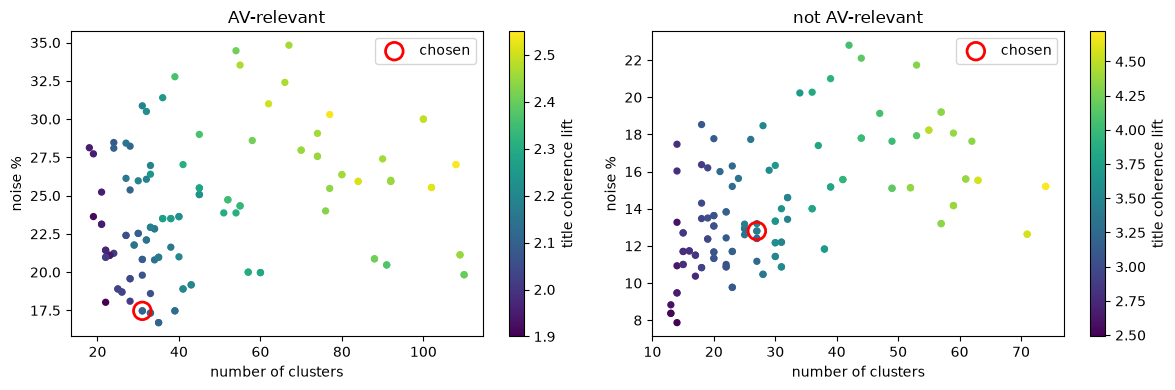

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (g, res) in zip(axes, results.items()):
    sc = ax.scatter(res.n_clusters, res.noise_pct, c=res.title_coherence_lift, cmap="viridis", s=18)
    c = chosen[g]
    ax.scatter([c.n_clusters], [c.noise_pct], s=160, facecolors="none", edgecolors="red", lw=2, label="chosen")
    ax.set_title(g); ax.set_xlabel("number of clusters"); ax.set_ylabel("noise %"); ax.legend()
    plt.colorbar(sc, ax=ax, label="title coherence lift")
plt.tight_layout(); plt.show()

In [17]:
# How each setting affects the chosen group's results, holding the others at the chosen values.
for g, res in results.items():
    c = chosen[g]
    print(f"\n{g}: effect of min_cluster_size (n_neighbors={int(c.n_neighbors)}, n_components={int(c.n_components)}, min_samples={int(c.min_samples)})")
    sub = res[(res.n_neighbors == c.n_neighbors) & (res.n_components == c.n_components) & (res.min_samples == c.min_samples)]
    print(sub[["min_cluster_size", "n_clusters", "noise_pct", "largest_pct", "title_coherence_lift", "self_contained", "seed_agreement"]].to_string(index=False))


AV-relevant: effect of min_cluster_size (n_neighbors=15, n_components=10, min_samples=1)
 min_cluster_size  n_clusters  noise_pct  largest_pct  title_coherence_lift  self_contained  seed_agreement
                8         109      21.13         3.67                  2.45            0.42            0.44
               10          88      20.87         5.10                  2.41            0.48            0.42
               15          57      20.00         6.83                  2.30            0.59            0.53
               20          41      18.90         8.57                  2.20            0.65            0.59
               25          35      16.70         8.57                  2.11            0.67            0.64
               30          31      17.47         8.57                  2.11            0.68            0.68
               40          25      18.90         8.57                  2.03            0.70            0.71

not AV-relevant: effect of min_cluster_size (

**Robustness check:** the same rule, run on the notebook's own vectors for the same model and chunk
size. These differ from the pipeline's only by floating-point noise, from a different batch size.
A choice worth trusting should come out the same, or differ only between settings whose scores are
effectively tied.

In [18]:
ALT = ce.embed(t, CHOSEN_MODEL, chunk_words=CHOSEN_CHUNK)[0]
print(f"largest difference between the two vector sets: {np.abs(ALT - VECS).max():.1e}")
keys = ["n_neighbors", "n_components", "min_cluster_size", "min_samples", "n_clusters", "noise_pct",
        "seed_agreement", "mean_rank"]
rows = []
for g, mask in groups.items():
    alt = ce.select(ce.tune_group(ALT[mask], df[mask].reset_index(drop=True), GRID), **RULES[g])
    for name, ranked in (("pipeline vectors (used)", ce.select(results[g], **RULES[g])), ("notebook vectors", alt)):
        # min_samples 1 and 2 often give identical clusters: list distinct results only.
        ranked = ranked.drop_duplicates(subset=["n_neighbors", "n_components", "min_cluster_size",
                                                "n_clusters", "noise_pct", "seed_agreement"])
        for place in range(2):
            rows.append({"group": g, "vectors": name, "place": place + 1, **ranked.iloc[place][keys].to_dict()})
pd.DataFrame(rows)

largest difference between the two vector sets: 1.5e-05


,group,vectors,place,n_neighbors,n_components,min_cluster_size,min_samples,n_clusters,noise_pct,seed_agreement,mean_rank
0,AV-relevant,pipeline vectors (used),1,15.0,10.0,30.0,1.0,31.0,17.47,0.68,3.250
1,AV-relevant,pipeline vectors (used),2,15.0,10.0,40.0,1.0,25.0,18.90,0.71,3.500
2,AV-relevant,notebook vectors,1,15.0,10.0,30.0,1.0,31.0,17.13,0.68,4.000
3,AV-relevant,notebook vectors,2,15.0,10.0,40.0,1.0,25.0,17.17,0.70,4.250
4,not AV-relevant,pipeline vectors (used),1,50.0,5.0,20.0,1.0,27.0,12.80,0.72,6.875
5,not AV-relevant,pipeline vectors (used),2,50.0,5.0,20.0,5.0,24.0,15.63,0.76,7.875
6,not AV-relevant,notebook vectors,1,30.0,10.0,20.0,2.0,27.0,11.00,0.74,6.750
7,not AV-relevant,notebook vectors,2,50.0,10.0,20.0,2.0,27.0,13.90,0.69,8.000


**Finding (decision 4).**

| Group | UMAP | HDBSCAN | Result (averaged over 3 seeds) |
|---|---|---|---|
| AV-relevant | 15 neighbours, **10** dimensions | min_cluster_size **30**, min_samples **1** | 31 clusters, 17% noise, largest 8.6%, seed agreement 0.68 |
| not AV-relevant | **50** neighbours, 5 dimensions | min_cluster_size **20**, min_samples **1** | 27 clusters, 13% noise, largest 9.2%, seed agreement 0.72 |

**What ruled settings out:**
- **AV group, 6 of 126 admissible:** 98 settings leave more than 20% of postings as noise, and 98 fall below 0.6 seed agreement (largely the same small-cluster settings).
- **Other group, 18 of 126 admissible:** 67 settings have one cluster holding over 10% of the group, and 45 fall below 0.6 seed agreement.

**The trade-off the rule balances** (the `min_cluster_size` tables):
- Small clusters have the most similar titles (coherence 2.45 at size 8, AV group).
- But they are the least self-contained (0.42) and the least reproducible (seed agreement 0.44), and there are 109 of them.
- From about size 25–30, coherence levels off while self-containment reaches 0.67–0.68 and seed agreement 0.64–0.71.
- `min_samples` 1 and 2 give identical results at the chosen settings.

**Robustness:**
- **AV group:** on the notebook's own vectors (a floating-point difference of 1.5×10⁻⁵), the revised rule picks **exactly the same** first and second settings.
- **Other group:** it picks a near-tied neighbour instead (30 neighbours / 10 dimensions rather than 50 / 5; mean rank 6.75 vs 6.88), with the **same `min_cluster_size` (20) and the same 27 clusters**.

So the cluster size and granularity are settled. The UMAP details for the other group are a coin-toss between equally good options.

**Employer concentration:** in the other group about 40% of clusters are at least 80% one company. These are mostly Bosch business units (heating, security systems, power tools, factories), which is a genuine feature of that group, since Bosch makes up 63% of it.

**Granularity:** these are broad job families (31 + 27). A finer level sits inside them: `min_cluster_size` 10 on the same UMAP gives about 88 AV clusters. It could be kept as specialisations, since the schema has both `job_family` and `specialisation`, but it is much less reproducible (seed agreement 0.42).

## 6. Chosen setup against the current one

**First, how fragile is the current clustering?** The pipeline saved the MiniLM vectors it clustered on.
Re-clustering those saved vectors must reproduce the stored clusters exactly, which checks that this
notebook's code matches the pipeline. Re-clustering vectors re-computed here, which differ from the
saved ones only by floating-point noise, shows how much the result depends on accidents.

In [19]:
from sklearn.metrics import adjusted_rand_score
stored = df.current_cluster.fillna(-1).to_numpy()
OLD_VECS = ce.embed(ce.texts(df, "A_all_skills"), "all-MiniLM-L6-v2")[0]
saved_path = ce.ROOT / ".cache" / "emb_e6cf966b361a82a6.npy"    # the full run's own MiniLM vectors
saved = np.load(saved_path) if saved_path.exists() else None
if saved is not None:
    print(f"largest difference between saved and re-computed vectors: {np.abs(saved - OLD_VECS).max():.1e}")
for g, mask in groups.items():
    line = f"{g:16}"
    if saved is not None:
        line += f" saved vectors -> ARI {adjusted_rand_score(stored[mask], ce.cluster_with(saved[mask], 15, 5, 8, 2)):.2f} |"
    line += f" re-computed vectors -> ARI {adjusted_rand_score(stored[mask], ce.cluster_with(OLD_VECS[mask], 15, 5, 8, 2)):.2f}"
    print(line)

largest difference between saved and re-computed vectors: 5.6e-08


AV-relevant      saved vectors -> ARI 1.00 | re-computed vectors -> ARI 0.49


not AV-relevant  saved vectors -> ARI 1.00 | re-computed vectors -> ARI 0.75


**Then the two setups side by side**, each with the current model and with the chosen one. Comparing
at equal settings separates the effect of the embedding model from the effect of the settings.

`seed_agreement` is the adjusted Rand index between seeds 42, 7 and 123 over **all** postings, noise
included. It is stricter than the `stability` column used in the selection rule, which only compares
postings clustered in both runs, and so misses postings that flip in and out of noise.

In [20]:
PARAMS = {"current": {g: (15, 5, 8, 2) for g in groups},
          "chosen": {g: tuple(int(chosen[g][k]) for k in ("n_neighbors", "n_components", "min_cluster_size", "min_samples"))
                     for g in groups}}
rows = []
final_labels = np.full(len(df), -1)
for g, mask in groups.items():
    sub = df[mask].reset_index(drop=True)
    base = ce.random_title_baseline(sub)
    for setting in ("current", "chosen"):
        for model_name, vecs in (("all-MiniLM-L6-v2", OLD_VECS), (CHOSEN_MODEL, VECS)):
            v = vecs[mask]
            labs = {seed: ce.cluster_with(v, *PARAMS[setting][g], seed=seed) for seed in (42, 7, 123)}
            m = ce.cluster_metrics(labs[42], v, sub, ce.knn(v, 15), base)
            rows.append({"group": g, "settings": setting, "model": model_name,
                         **{k: m[k] for k in ("n_clusters", "noise_pct", "largest_pct", "title_coherence_lift", "single_company_pct")},
                         "seed_agreement": round(np.mean([adjusted_rand_score(labs[42], labs[x]) for x in (7, 123)]), 2)})
            if setting == "chosen" and model_name == CHOSEN_MODEL:
                final_labels[np.where(mask)[0]] = np.where(labs[42] >= 0, labs[42] + (0 if g == "AV-relevant" else 1000), -1)
df["new_cluster"] = final_labels
pd.DataFrame(rows)

,group,settings,model,n_clusters,noise_pct,largest_pct,title_coherence_lift,single_company_pct,seed_agreement
0,AV-relevant,current,all-MiniLM-L6-v2,122,22.9,4.3,2.39,8.2,0.48
1,AV-relevant,current,gte-base,106,18.7,3.8,2.42,10.4,0.51
2,AV-relevant,chosen,all-MiniLM-L6-v2,25,10.3,10.9,1.78,0.0,0.60
3,AV-relevant,chosen,gte-base,31,15.3,8.4,2.13,3.2,0.68
4,not AV-relevant,current,all-MiniLM-L6-v2,76,15.6,5.2,4.31,48.7,0.45
5,not AV-relevant,current,gte-base,73,14.3,3.8,5.00,49.3,0.49
6,not AV-relevant,chosen,all-MiniLM-L6-v2,22,12.7,11.3,2.80,40.9,0.63
7,not AV-relevant,chosen,gte-base,27,13.8,9.3,3.41,44.4,0.72


`title_coherence_lift` naturally falls as clusters get broader, because a family holds more varied
titles than a narrow group does. So it compares models at **equal** settings, not the two
granularities.

**Problem cases from the cluster review, and where they land now** (old cluster → new clusters, with
counts; −1 means noise):

In [21]:
cases = {"safety drivers / AV operators": [21, 22], "perception": [51, 100, 101],
         "behaviour & planning ML": [111, 112, 113], "Buderus sales reps": [123, 125],
         "product managers": [58, 59], "mixed grab-bag": [165, 35]}
for name, old_ids in cases.items():
    part = df[df.current_cluster.isin(old_ids)]
    spread = part.groupby("current_cluster").new_cluster.agg(lambda s: dict(s.value_counts().head(3)))
    print(f"{name}:")
    for old_id, new in spread.items():
        print(f"   old {old_id:>3} -> new {new}")

safety drivers / AV operators:
   old  21 -> new {21: np.int64(14)}
   old  22 -> new {21: np.int64(17)}
perception:
   old  51 -> new {-1: np.int64(5), 26: np.int64(2), 2: np.int64(1)}
   old 100 -> new {26: np.int64(87), -1: np.int64(7), 29: np.int64(5)}
   old 101 -> new {-1: np.int64(11), 26: np.int64(1), 25: np.int64(1)}
behaviour & planning ML:
   old 111 -> new {29: np.int64(6), 30: np.int64(4), -1: np.int64(3)}
   old 112 -> new {29: np.int64(13), -1: np.int64(2), 27: np.int64(1)}
   old 113 -> new {29: np.int64(23), 26: np.int64(1), 30: np.int64(1)}
Buderus sales reps:
   old 123 -> new {1003: np.int64(16), -1: np.int64(1)}
   old 125 -> new {1003: np.int64(9)}
product managers:
   old  58 -> new {10: np.int64(9), 11: np.int64(2), 7: np.int64(1)}
   old  59 -> new {10: np.int64(8)}
mixed grab-bag:
   old  35 -> new {-1: np.int64(6), 15: np.int64(2)}
   old 165 -> new {1019: np.int64(6), -1: np.int64(4)}


In [22]:
# The largest new clusters in each group: example titles, for a first look (names are for people to give).
for g, mask in groups.items():
    sub = df[mask & (df.new_cluster >= 0)]
    print(f"\n{g}: {sub.new_cluster.nunique()} clusters")
    for cid, n in sub.new_cluster.value_counts().head(8).items():
        part = sub[sub.new_cluster == cid]
        titles = " | ".join(part.title.str.strip().value_counts().head(5).index)
        print(f"  {cid:>5} ({n:>3}, {part.company.nunique():>2} companies): {titles[:150]}")


AV-relevant: 31 clusters
      4 (245, 31 companies): Embedded Software Engineer | Software Engineer | Senior Software Engineer | Application Software Engineer | Vehicle Application Engineer
     22 (179, 27 companies): [42dot Vietnam] QA Engineer (Automotive) | QA Engineer | Test Engineer | Firmware Validation Engineer | Manufacturing Test Engineer
     28 (143, 29 companies): Senior Software Engineer, ML Infrastructure | Senior Machine Learning Engineer - AI Foundation | AI compiler R&D engineer | Deep Learning Engineer (Sp
     26 (119, 24 companies): Senior Machine Learning Engineer - Perception | Lead Perception Engineer | Perception Algorithm Engineer (End-to-End Direction) | End-to-end perceptio
     29 (117, 28 companies): Machine Learning Engineer | Machine Learning Software Engineer | Research Scientist (Research) | Machine Learning Engineer - Behavior and Planning | R
     27 (114, 26 companies): Senior Software Engineer - Data Infrastructure | Data Engineer | Senior Data A

**Finding: the chosen setup against the current one.**

**1. The current clustering is fragile.**
- Re-clustering the pipeline's own saved vectors reproduces the stored clusters exactly (ARI 1.00), so this notebook's code matches the pipeline.
- Re-computed vectors differ from the saved ones only by floating-point noise (about 6×10⁻⁸). Yet they reproduce **about half of the AV clustering (ARI 0.49)**, and 0.75 for the other group. The same effect is why the re-run "current" rows above show 122 + 76 clusters rather than the stored 114 + 70.
- **The chosen setup is far more reproducible:** seed agreement **0.68 / 0.72**, against 0.51 / 0.49 for the current settings with the same model.

**2. The model effect at equal settings:** gte-base gives more coherent clusters than MiniLM in all four comparisons.

| | AV group | Other group |
|---|---|---|
| current settings | 2.42 vs 2.39 | 5.00 vs 4.31 |
| chosen settings | 2.13 vs 1.78 | 3.41 vs 2.80 |

**3. The settings effect:**
- **Far fewer clusters:** 31 + 27 instead of the stored 114 + 70.
- **Less noise:** 15% vs 23% for the AV group; 14% vs 16% for the other group.
- **Lower title coherence than at size 8,** because broader families hold more varied titles. That's the price of groups stable enough to label once.

**4. The cluster review's problem cases:**
- **Merged into one cluster each:**
  - safety drivers and AV operators (old 21 + 22)
  - Buderus sales reps (123 + 125)
  - product managers (58 + 59)
  - perception (old 100: 87 of its 103 postings)
- **Mostly merged:** behaviour & planning ML (111–113).
- **Now mostly noise, or split into neighbouring clusters:** the incoherent grab-bags (35, 165).
- **One regression:** the radar/lidar algorithm postings (old 101) now fall mostly into noise, instead of joining the perception cluster.

**5. The largest new clusters are broad families from many companies.** For example, the largest AV cluster has 245 postings from 31 companies, with titles such as "Embedded Software Engineer" and "Application Software Engineer". Names are left for people to give.

**One relevance issue is visible here:** a cluster of drone, UAV and defence-autonomy roles (65 postings, 9 companies) sits in the **not AV-relevant** group. The model marked these not relevant with high confidence, although the prompt asks for Low confidence on non-vehicle autonomy. That's a prompt matter, not a clustering one.

## 7. Decisions carried into the pipeline

The settings chosen above are written into `avjobs/config.py` and `run_pipeline_v2.cluster_text`.
Re-running the pipeline with `--db` reuses every record from the database (no LLM calls), and
re-embeds and re-clusters with the new settings.

In [23]:
decisions = pd.DataFrame([
    {"setting": "embedded text", "before": "A_all_skills", "after": CHOSEN_TEXT, "evidence": "section 2"},
    {"setting": "EMBED_MODEL", "before": "all-MiniLM-L6-v2", "after": CHOSEN_MODEL, "evidence": "section 3"},
    {"setting": "CHUNK_WORDS", "before": 160, "after": CHOSEN_CHUNK, "evidence": "section 4"},
] + [
    {"setting": f"{k} ({g})", "before": v_old, "after": int(chosen[g][k]), "evidence": "section 5"}
    for g in groups for k, v_old in (("n_neighbors", 15), ("n_components", 5), ("min_cluster_size", 8), ("min_samples", 2))
])
decisions

,setting,before,after,evidence
0,embedded text,A_all_skills,A_all_skills,section 2
1,EMBED_MODEL,all-MiniLM-L6-v2,gte-base,section 3
2,CHUNK_WORDS,160,350,section 4
3,n_neighbors (AV-relevant),15,15,section 5
4,n_components (AV-relevant),5,10,section 5
5,min_cluster_size (AV-relevant),8,30,section 5
6,min_samples (AV-relevant),2,1,section 5
7,n_neighbors (not AV-relevant),15,50,section 5
8,n_components (not AV-relevant),5,5,section 5
9,min_cluster_size (not AV-relevant),8,20,section 5
